In [1]:
from esda.moran import Moran
import pandas as pd
import numpy as np
import libpysal.weights.set_operations as Wsets
from libpysal.weights import Queen, KNN
import seaborn as sns
from libpysal import weights
import geopandas as gpd
import contextily as cx
from sklearn import cluster
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import contextily as ctx

In [2]:
gdf=gpd.read_file(r"carto\cuencas_Gauss.gpkg")
w=Queen.from_dataframe(gdf)
variables=['FRA','Beta_media']
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   HYBAS_ID        72 non-null     int64   
 1   SUB_AREA        72 non-null     float64 
 2   cod_ah          72 non-null     float64 
 3   nom_ah          72 non-null     str     
 4   cod_zh          72 non-null     float64 
 5   nom_zh          72 non-null     str     
 6   cod_szh         72 non-null     float64 
 7   nom_szh         72 non-null     str     
 8   PMA_cuenca      72 non-null     float64 
 9   altura_mean     72 non-null     float64 
 10  area[km2]       72 non-null     float64 
 11  Beta_media      72 non-null     float64 
 12  Beta_std        72 non-null     float64 
 13  P24_media       72 non-null     float64 
 14  P24_std         72 non-null     float64 
 15  index_extremal  72 non-null     float64 
 16  FRA             72 non-null     float64 
 17  FRA_pred  

C:\Users\DAVID01\AppData\Local\Temp\ipykernel_24532\671225726.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w=Queen.from_dataframe(gdf)


In [3]:
# Variable estandarizada
var_std=StandardScaler().fit_transform(gdf[variables])

In [4]:
from sklearn.metrics import silhouette_score

# =====================================================
# 1. RANGO DE NÚMERO DE CLÚSTERES
# =====================================================

# El capítulo propone evaluar desde K = 2 hasta K = 8
k_max = min(8, len(gdf) - 1)

if k_max < 2:
    raise ValueError(
        "No hay suficientes estaciones para evaluar el clustering."
    )

rango_k = range(2, k_max + 1)

# =====================================================
# 2. LISTAS PARA GUARDAR RESULTADOS
# =====================================================

inercias = []
silhouettes = []

# =====================================================
# 3. AJUSTAR K-MEANS PARA CADA VALOR DE K
# =====================================================

for k in rango_k:

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    etiquetas = modelo.fit_predict(var_std)

    # Suma de cuadrados de las distancias internas
    inercias.append(modelo.inertia_)

    # Calidad de separación de los grupos
    silhouettes.append(
        silhouette_score(var_std, etiquetas)
    )

# =====================================================
# 4. TABLA DE RESULTADOS
# =====================================================

resultados_k = pd.DataFrame({
    "K": list(rango_k),
    "Inercia": inercias,
    "Silhouette": silhouettes
})

display(resultados_k.round(4))

,K,Inercia,Silhouette
0,2,80.2676,0.4300
1,3,44.9930,0.4934
2,4,33.2150,0.4229
3,5,24.6747,0.4332
4,6,19.2029,0.4344
5,7,16.3073,0.4118
6,8,14.0477,0.4151


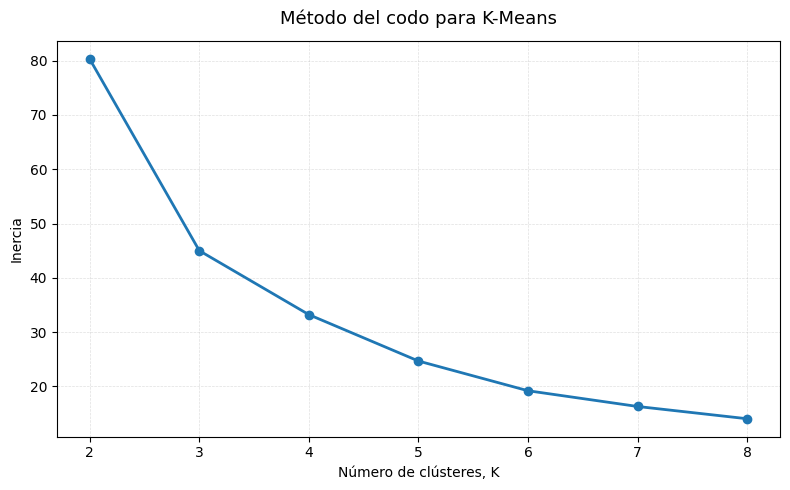

In [5]:
# =====================================================
# 5. GRÁFICA DEL MÉTODO DEL CODO
# =====================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    resultados_k["K"],
    resultados_k["Inercia"],
    marker="o",
    linewidth=2
)

ax.set_title(
    "Método del codo para K-Means",
    fontsize=13,
    pad=12
)

ax.set_xlabel("Número de clústeres, K")
ax.set_ylabel("Inercia")

ax.set_xticks(resultados_k["K"])

ax.grid(
    True,
    linestyle="--",
    linewidth=0.5,
    alpha=0.4
)

plt.tight_layout()
plt.show()

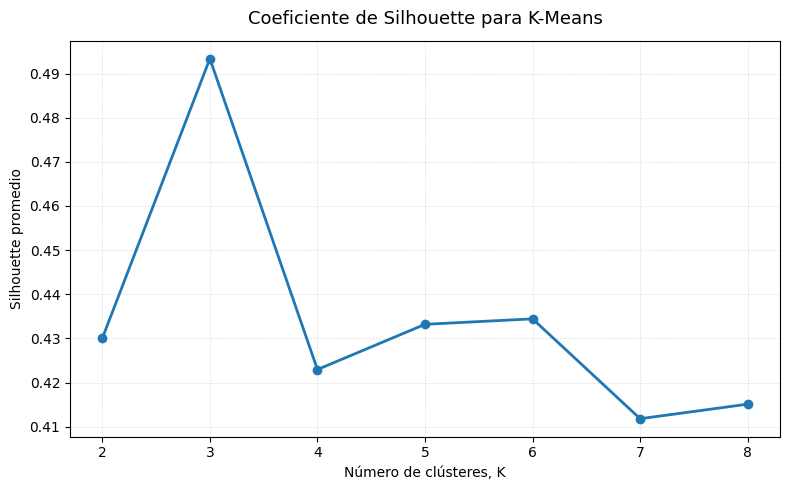

In [6]:
# =====================================================
# 6. GRÁFICA DEL COEFICIENTE DE SILHOUETTE
# =====================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    resultados_k["K"],
    resultados_k["Silhouette"],
    marker="o",
    linewidth=2
)

ax.set_title(
    "Coeficiente de Silhouette para K-Means",
    fontsize=13,
    pad=12
)

ax.set_xlabel("Número de clústeres, K")
ax.set_ylabel("Silhouette promedio")

ax.set_xticks(resultados_k["K"])

ax.grid(
    True,
    linestyle="--",
    linewidth=0.5,
    alpha=0.4
)

plt.tight_layout()
plt.show()

In [15]:
k_elegido=2

In [16]:
# =====================================================
# K-MEANS CONVENCIONAL
# =====================================================

modelo_kmeans = KMeans(
    n_clusters=k_elegido,
    random_state=42,
    n_init=20
)

gdf["cluster_kmeans"] = modelo_kmeans.fit_predict(
    var_std
)

print("Número de cuencas por clúster K-means:")

display(
    gdf.groupby("cluster_kmeans")
    .size()
    .rename("Numero_cuencas")
    .to_frame()
)

Número de cuencas por clúster K-means:


,Numero_cuencas
cluster_kmeans,
0,26
1,46


In [17]:
# =====================================================
# AGRUPAMIENTO ESPACIAL AGLOMERATIVO
# =====================================================

modelo_espacial = AgglomerativeClustering(
    n_clusters=k_elegido,
    linkage="ward",
    connectivity=w.sparse
)

gdf["cluster_espacial"] = modelo_espacial.fit_predict(
    var_std
)

print("Número de cuencas por clúster espacial:")

display(
    gdf.groupby("cluster_espacial")
    .size()
    .rename("Numero_cuencas")
    .to_frame()
)

Número de cuencas por clúster espacial:


,Numero_cuencas
cluster_espacial,
0,53
1,19


In [18]:
# =====================================================
# CARACTERIZACIÓN DEL K-MEANS
# =====================================================

resumen_kmeans = (
    gdf.groupby("cluster_kmeans")[variables]
    .agg(
        ["count", "mean"]
    )
)

display(resumen_kmeans.round(3))

FRA        Beta_media       
               count   mean      count   mean
cluster_kmeans                               
0                 26  0.820         26 -0.614
1                 46  0.644         46 -0.548

In [19]:
# =====================================================
# CARACTERIZACIÓN DEL CLUSTERING ESPACIAL
# =====================================================

resumen_espacial = (
    gdf.groupby("cluster_espacial")[variables]
    .agg(
        ["count", "mean"]
    )
)

display(resumen_espacial.round(3))

FRA        Beta_media       
                 count   mean      count   mean
cluster_espacial                               
0                   53  0.686         53 -0.558
1                   19  0.768         19 -0.611

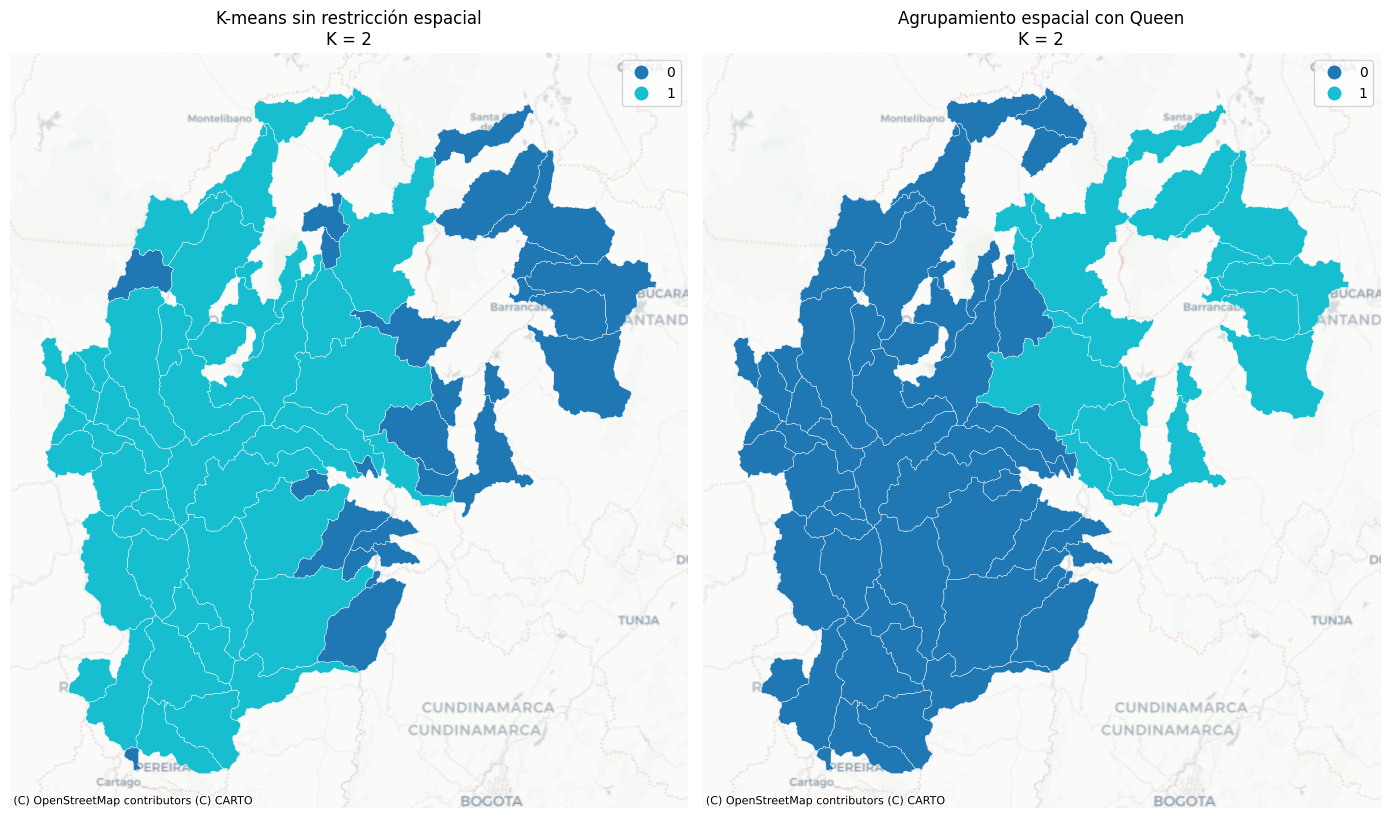

In [20]:
# =====================================================
# COMPARACIÓN CARTOGRÁFICA
# =====================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 8)
)

# -----------------------------------------------------
# K-MEANS CONVENCIONAL
# -----------------------------------------------------

gdf.plot(
    column="cluster_kmeans",
    categorical=True,
    cmap="tab10",
    legend=True,
    edgecolor="white",
    linewidth=0.3,
    ax=axes[0]
)

ctx.add_basemap(
    axes[0],
    source=ctx.providers.CartoDB.Positron,
    crs=gdf.crs
)

axes[0].set_title(
    f"K-means sin restricción espacial\nK = {k_elegido}"
)

axes[0].set_axis_off()

# -----------------------------------------------------
# AGRUPAMIENTO ESPACIAL
# -----------------------------------------------------

gdf.plot(
    column="cluster_espacial",
    categorical=True,
    cmap="tab10",
    legend=True,
    edgecolor="white",
    linewidth=0.3,
    ax=axes[1]
)

ctx.add_basemap(
    axes[1],
    source=ctx.providers.CartoDB.Positron,
    crs=gdf.crs
)

axes[1].set_title(
    f"Agrupamiento espacial con Queen\nK = {k_elegido}"
)

axes[1].set_axis_off()

plt.tight_layout()
plt.show()

<Axes: title={'center': 'FRA'}, xlabel='cluster_espacial'>

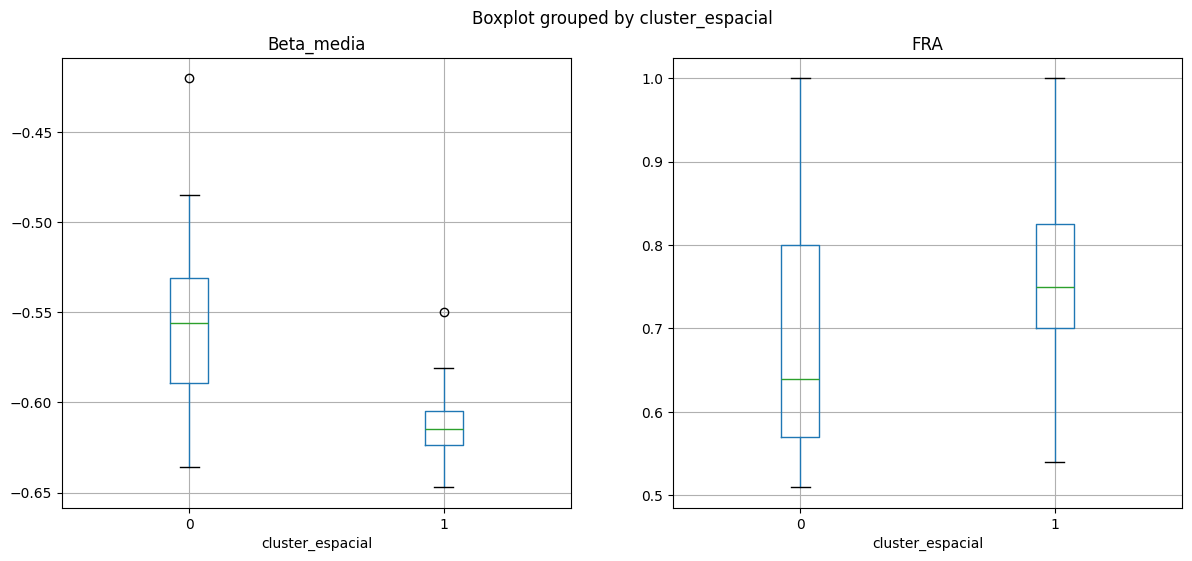

In [21]:
f,ax=plt.subplots(1,2,figsize=(14,6))
gdf.boxplot(column=['Beta_media'], by='cluster_espacial', ax=ax[0])
gdf.boxplot(column=['FRA'], by='cluster_espacial', ax=ax[1])


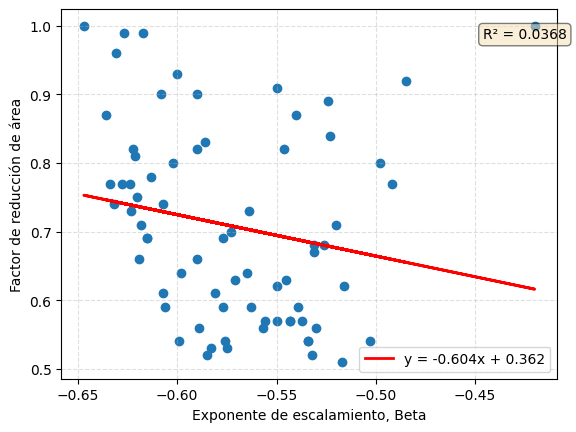

In [22]:
# Comparar gráfico de dispersión entre Beta y P media 
plt.scatter(gdf["Beta_media"], gdf["FRA"])

plt.ylabel("Factor de reducción de área")
plt.xlabel("Exponente de escalamiento, Beta")
plt.grid(True, linestyle="--", alpha=0.4)

# Ajustar línea recta usando numpy
z = np.polyfit(gdf["Beta_media"], gdf["FRA"], 1)
p = np.poly1d(z)
plt.plot(gdf["Beta_media"], p(gdf["Beta_media"]), "r-", linewidth=2, label=f"y = {z[0]:.3f}x + {z[1]:.3f}")

# Calcular R²
ss_res = np.sum((gdf["FRA"] - p(gdf["Beta_media"])) ** 2)
ss_tot = np.sum((gdf["FRA"] - gdf["FRA"].mean()) ** 2)
r2 = 1 - (ss_res / ss_tot)

plt.text(0.85, 0.95, f"R² = {r2:.4f}", transform=plt.gca().transAxes, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.legend()
plt.show()